# Case Study 1: Predicting Superconductor Critical Temperature
### Eric Graham
### DS 7333: Quantifying the World
### Dr. Robert Slater


## Feedback from First Draft

Dr. Slater: I address these inline throughout the notebook, but wanted to put some quick answers up top just for convenience.

**1. Convergence warnings**
The warnings came from sklearn's Lasso coordinate descent failing to converge at very low alpha values (as low as 0.001) during the lambda search. They could have been prevented by increasing max_iter. My concern is whether the final fitted model converges: the 167-feature L1 at lambda 0.178 does, while the 81-feature model at lambda 0.001 does not.

**2. L2 lambda unusually low**
The L2 lambda search was updated to record CV MSE at every alpha and plot the full curve. The plot shows CV MSE is essentially flat from lambda = 0.001 to lambda = 1, then rises steeply. The 0.1 result is the "winner" on a wide, shallow plateau. This reflects that L2 has very little overfitting to correct on the 81-feature dataset until the penalty becomes large.

**3. Regularization had little effect**
The 81-feature dataset has ~21K observations and 81 features, which makes OLS already stable. Regularization corrects overfitting, so when there is none to correct, it adds no value. The near-zero L1 lambdas confirm this.

**4. What is the difference between MSE and RMSE?**
MSE (Mean Squared Error) is the average squared difference between predictions and actuals, expressed in squared units (K² here). It is useful as the loss function but not directly interpretable. RMSE is the square root of MSE, which returns the error to the original unit (Kelvin) and is what we report throughout. An RMSE of ~17 K means the model is off by roughly 17 degrees on average against a target range of 0–185 K.

**5. Adding unique_m.csv**
This did improve model performance! Adding the 86 elemental composition features (df_167, 167 features total) reduced OLS RMSE from 17.38 K to 16.51 K. The improvement held across model types. Ba and Bi emerged as top features in the 167-feature models, suggesting the composition features added genuine signal beyond what the aggregated features had.

## Introduction

For this case study, we are presented with a dataset of 21,263 superconducting materials, each described by 81 engineered features derived from the elements that make up those compounds, along with 86 features describing how much of any given element is present in each compound. Our goal is to predict each material's critical temperature (the temperature at which it becomes superconductive) using linear regression models with L1 (Lasso) and L2 (Ridge) regularization. We will compare the performance of both models and identify the ten most important features driving each model's predictions.

## Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error

# note: L1 on the 81-feature datasest had trouble converging on a value for lambda, so I suppressed warnings to make the output doc more readable. I ran once again with warnings, so I could capture them for discussion, following Dr. Slater's feedback, but they remain suppressed in the final notebook to keep the output from being cluttered.
import warnings
warnings.filterwarnings('ignore')

print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"sklearn:    {sklearn.__version__}")

pandas:     3.0.3
numpy:      2.4.4
matplotlib: 3.10.9
sklearn:    1.8.0


## Read In Data

### Two Datasets -> Two Dataframes

My initial draft of this assignment ignored the unique_m.csv file from our dataset, which was an error. unique_m.csv describes the elemental composition of each compound, which adds 86 features to the dataset. For educational purposes, I'm going to include both the original models (with only the 81 aggregated features) and the full models (with all 167 features) so we can see where we went wrong. Before joining the two datasets I compared the critical temperature values of each row index to confirm they lined up.

In [2]:
df_raw = pd.read_csv("data/train.csv")
df_comp_raw = pd.read_csv("data/unique_m.csv")

aligned = (df_raw['critical_temp'] == df_comp_raw['critical_temp']).all()
print(f"Row alignment verified: {aligned}")

df_81 = df_raw.copy()

comp_features = df_comp_raw.drop(columns=["critical_temp", "material"])
df_167 = df_raw.join(comp_features)

print(f"df_81 shape:  {df_81.shape}")   # expect (21263, 82)
print(f"df_167 shape: {df_167.shape}")  # expect (21263, 168)

Row alignment verified: True
df_81 shape:  (21263, 82)
df_167 shape: (21263, 168)


## Exploratory Data Analysis

Before setting up the data pipeline and fitting the model, we want to do a quick missingness check and look at the distribution of the target variable.

### Missingness Check

Although introductory videos for Case Study 1 indicate that there is no missing data, it's prudent to always do some sort of check for missing values.

In [3]:
print(df_81.isnull().sum().sum())
print(df_167.isnull().sum().sum())

0
0


### Distribution of Target Variable

As shown in the histogram below, our target variable (critical_temp) is heavily right-skewed, with the majority of observations having a critical temperature near 0. This skewness in the target variable can bias the model towards lower temperatures. One approach to this would be to try a log transformation on the target variable, but that introduces additional complexity to a project which emphasizes interpretability, so we proceed with the untransformed target variable to remain consistent with the modeling approach demonstrated in the course materials.

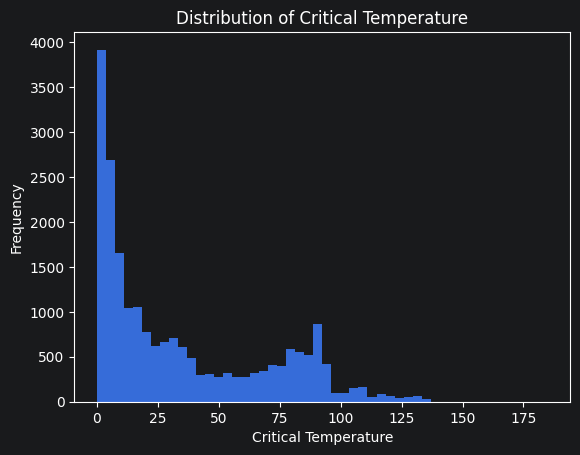

In [4]:
plt.hist(df_81['critical_temp'], bins=50)
plt.xlabel('Critical Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of Critical Temperature')
plt.show()

## Preprocessing

First, we identify the features (X) and target variable (y). Then, we create an 80/20 train/test split and fit our scaler to the training data. This simulates real-world conditions in which you wouldn't be able to fit a scaler to the unknown data that you are predicting against.


In [5]:
X_81 = df_81.drop(columns='critical_temp')
y_81 = df_81['critical_temp']
X_train_81, X_test_81, y_train_81, y_test_81 = train_test_split(X_81, y_81, test_size=0.2, random_state=42)
scaler_81 = StandardScaler()
X_train_scaled_81 = scaler_81.fit_transform(X_train_81)
X_test_scaled_81 = scaler_81.transform(X_test_81)

In [6]:
X_167 = df_167.drop(columns='critical_temp')
y_167 = df_167['critical_temp']
X_train_167, X_test_167, y_train_167, y_test_167 = train_test_split(X_167, y_167, test_size=0.2, random_state=42)
scaler_167 = StandardScaler()
X_train_scaled_167 = scaler_167.fit_transform(X_train_167)
X_test_scaled_167 = scaler_167.transform(X_test_167)

## Plain Linear Baseline

Strictly for the purposes of comparison, we include an unmodified linear model with all features to serve as a baseline.

### Baseline Model on 81 Features

The MSE of 302.01 is in squared Kelvin (K²). This metric is useful for modeling but not as human-interpretable. Taking the square root gives RMSE, which returns to the original unit (K) and is what we report for interpretability. An RMSE of 17.38 means the model is off by roughly 17 degrees on average, against a target range of 0–185 K.


In [7]:
baseline_81 = LinearRegression()
baseline_81.fit(X_train_scaled_81, y_train_81)
baseline_preds_81 = baseline_81.predict(X_test_scaled_81)
baseline_mse_81 = mean_squared_error(y_test_81, baseline_preds_81)
print(f"Baseline MSE (81):  {baseline_mse_81:.4f}")
print(f"Baseline RMSE (81): {np.sqrt(baseline_mse_81):.4f}")

Baseline MSE (81):  302.0075
Baseline RMSE (81): 17.3784


### Baseline Model on 167 Features

Adding the 86 composition features brings RMSE down to 16.51 K, a modest improvement over the 81-feature baseline (17.38 K). All subsequent model comparisons use RMSE for the same reason: it lives in the same unit as the prediction target.

But in both cases, given the range of temperatures (0 to ~185), I think we can find a better RMSE!

In [8]:
baseline_167 = LinearRegression()
baseline_167.fit(X_train_scaled_167, y_train_167)
baseline_preds_167 = baseline_167.predict(X_test_scaled_167)
baseline_mse_167 = mean_squared_error(y_test_167, baseline_preds_167)
print(f"Baseline MSE (167):  {baseline_mse_167:.4f}")
print(f"Baseline RMSE (167): {np.sqrt(baseline_mse_167):.4f}")

Baseline MSE (167):  272.6843
Baseline RMSE (167): 16.5132


In [9]:
results = {}
results['Baseline_81']  = {'MSE': baseline_mse_81,  'RMSE': np.sqrt(baseline_mse_81)}
results['Baseline_167'] = {'MSE': baseline_mse_167, 'RMSE': np.sqrt(baseline_mse_167)}

## L1 (LASSO) Regression

L1 regression's penalty term is the absolute value of the coefficients.

$$J = \frac{1}{n} \sum_{i=1}^{n} \left(Y_i - \sum_{j=0}^{k} m_j x_{ij}\right)^2 + \lambda \sum_{j=0}^{k} |m_j|$$

This has the effect of reducing coefficients for the least predictive features to zero, reducing the number of features in the model (sparsity). This makes it a powerful option for feature selection and interpretability at the expense of predictive power: the features that L1 effectively removes from the model can still carry some predictive signal.

### Finding Lambda for L1

Lambda is the critical hyperparameter that we tune here: as shown in the example notebook, we use the logspace function from numpy to generate 25 lambda values across a logarithmic range. We initialize placeholders for the best score and best lambda value before looping through the 25 generated lambda values using 5-fold cross-validation (which adds another layer of rigor in our effort to find the most generalizable model). The best lambda value found in this process is then used in our fitted model, which we run against the test data.

### L1 Lambda Search and Model-Fitting on 81-Feature Dataset

This model had difficulty converging on a best value for lambda, even after tightening the range of the logspace. It settled on a best alpha of 0.001, which suggests that very little regularization is optimal for L1 on this dataset.

The best lambda we found (0.001) is so small that we are very close to the coefficients of the baseline model, and the fitted model with this lambda performs comparably to the baseline on our test data (RMSE of 17.48). This suggests that the weak regularization did little to improve on ordinary linear regression. The 81-feature dataset has a favorable sample-to-feature ratio: the model isn't overfitting badly enough to benefit from L1 regularization. The wider dataset may see more benefit from L1.

In [10]:
lambdas = np.logspace(-3, 3, 25)
best_score_81 = -1e99
best_lambda_81 = -1
for lam in lambdas:
    model = Lasso(alpha=lam)
    scores = cross_val_score(model, X_train_scaled_81, y_train_81, cv=5, scoring='neg_mean_squared_error')
    if scores.mean() > best_score_81:
        best_score_81 = scores.mean()
        best_lambda_81 = lam
print(f"Best alpha (81):  {best_lambda_81:.6f}")
print(f"Best CV MSE (81): {-best_score_81:.4f}")

/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.919e+06, tolerance: 1.598e+03
  model = cd_fast.enet_coordinate_descent(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.966e+06, tolerance: 1.612e+03
  model = cd_fast.enet_coordinate_descent(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number o

Best alpha (81):  0.001000
Best CV MSE (81): 315.6026


In [11]:
lasso_81 = Lasso(alpha=best_lambda_81)
lasso_81.fit(X_train_scaled_81, y_train_81)
lasso_preds_81 = lasso_81.predict(X_test_scaled_81)
lasso_mse_81 = mean_squared_error(y_test_81, lasso_preds_81)
print(f"Lasso MSE (81):  {lasso_mse_81:.4f}")
print(f"Lasso RMSE (81): {np.sqrt(lasso_mse_81):.4f}")

Lasso MSE (81):  305.5835
Lasso RMSE (81): 17.4809


/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.445e+06, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(


### L1 Lambda Search and Model-Fitting on 167-Feature Dataset

Adding the 86 composition features introduced sufficient redundancy and collinearity that L1 has some features to suppress, netting us an optimal Lambda of 0.1778.

However, this doesn't translate to improved performance compared to the OLS model with 167 features: the MSE/RMSE for the full OLS model was 272.68/16.51, compared to 290.42/17.04 on the full L1 model. This suggests not only that the OLS might not be overfit, but that the suppressed coefficients in the L1 model are actually carrying valuable signal which is benefitting the OLS model. However, the performance difference is small: we're still in the same ballpark RMSE-wise.

While L1 regularization is helpful for feature selection it might not be as effective as L2 regularization at actually reducing overfitting, which we will explore below.

### Note on Convergence Failure Warnings

During the lambda searches on both datasets, sklearn raised "ConvergenceWarning: Objective did not converge."  This means that coordinate descent never found a point at which iterative coefficient adjustments stopped producing meaningful reductions in loss, and that it may not have found the true optimum value.

This is not surprising: the search evaluates alphas as low as 0.001, and at those values convergence is unlikely regardless of feature set. What matters is whether the final fitted model converges. The 167-feature fitted model at alpha=0.178 does not produce this warning: the penalty is large enough that the solver reaches convergence cleanly. The 81-feature fitted model at alpha=0.001 does raise the warning, for the same reason the search warned: the regularization is effectively zero with such a low alpha.


In [12]:
best_score_167 = -1e99
best_lambda_167 = -1
for lam in lambdas:
    model = Lasso(alpha=lam)
    scores = cross_val_score(model, X_train_scaled_167, y_train_167, cv=5, scoring='neg_mean_squared_error')
    if scores.mean() > best_score_167:
        best_score_167 = scores.mean()
        best_lambda_167 = lam
print(f"Best lambda (167):  {best_lambda_167:.6f}")
print(f"Best CV MSE (167): {-best_score_167:.4f}")

/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.502e+06, tolerance: 1.598e+03
  model = cd_fast.enet_coordinate_descent(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.581e+06, tolerance: 1.612e+03
  model = cd_fast.enet_coordinate_descent(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number o

Best alpha (167):  0.177828
Best CV MSE (167): 327.6315


In [13]:
lasso_167 = Lasso(alpha=best_lambda_167)
lasso_167.fit(X_train_scaled_167, y_train_167)
lasso_preds_167 = lasso_167.predict(X_test_scaled_167)
lasso_mse_167 = mean_squared_error(y_test_167, lasso_preds_167)
print(f"Lasso MSE (167):  {lasso_mse_167:.4f}")
print(f"Lasso RMSE (167): {np.sqrt(lasso_mse_167):.4f}")

Lasso MSE (167):  290.4173
Lasso RMSE (167): 17.0416


In [14]:
results['Lasso_81']  = {'MSE': lasso_mse_81,  'RMSE': np.sqrt(lasso_mse_81)}
results['Lasso_167'] = {'MSE': lasso_mse_167, 'RMSE': np.sqrt(lasso_mse_167)}

## L2 (Ridge) Regression

L2 regression's penalty term is the squared value of the coefficients.

$$J = \frac{1}{n} \sum_{i=1}^{n} \left(Y_i - \sum_{j=0}^{k} m_j x_{ij}\right)^2 + \lambda \sum_{j=0}^{k} m_j^2$$

Unlike L1, L2 shrinks all coefficients _towards_ zero without reducing any to zero. This means all features remain in the model, allowing even weak predictors to contribute their signal. This makes Ridge the stronger choice for predictive accuracy, though it means it isn't useful for feature selection and we sacrifice some of L1's interpretability by leaving in every feature.

We take the same approach to finding the best lambda value for L2 as we did for L1.

### L2 Lambda Search and Model-Fitting on 81-Feature Dataset

L2 for the 81-feature model found a best lambda of 0.1, a more impactful level of regularization than the 81-feature L1's 0.001.

This is still quite low, so I visualized the cross-validated MSE scores for each alpha value in our search. We see that error is essentially flat from lambda = .001 to lambda = 1, then rises steeply. Any lambda value in that range would have produced similar results. This further suggests that the base OLS model isn't overfit for the 81-feature dataset, and that the 81-feature dataset doesn't benefit much from regularization.

The fitted Ridge model (α = 0.1) performs nearly identically to the baseline when run against our test data (RMSE of 17.38). While L2 found a more meaningful level of regularization than L1, the marginal improvement suggests that for this dataset, regularization doesn't have a significant impact on prediction error.

Best alpha (81):  0.100000
Best CV MSE (81): 313.3271


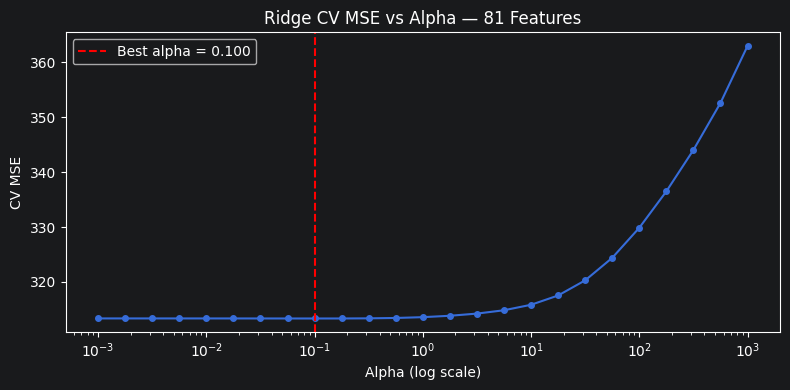

In [28]:
lambdas = np.logspace(-3, 3, 25)
best_score_ridge_81 = -1e99
best_lambda_ridge_81 = -1
all_scores_ridge_81 = []
for lam in lambdas:
    model = Ridge(alpha=lam)
    scores = cross_val_score(model, X_train_scaled_81, y_train_81, cv=5, scoring='neg_mean_squared_error')
    all_scores_ridge_81.append(-scores.mean())
    if scores.mean() > best_score_ridge_81:
        best_score_ridge_81 = scores.mean()
        best_lambda_ridge_81 = lam
print(f"Best lambda (81):  {best_lambda_ridge_81:.6f}")
print(f"Best CV MSE (81): {-best_score_ridge_81:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(lambdas, all_scores_ridge_81, marker='o', markersize=4)
plt.axvline(best_lambda_ridge_81, color='red', linestyle='--', label=f'Best alpha = {best_lambda_ridge_81:.3f}')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('CV MSE')
plt.title('Ridge CV MSE vs Lambda — 81 Features')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
ridge_81 = Ridge(alpha=best_lambda_ridge_81)
ridge_81.fit(X_train_scaled_81, y_train_81)
ridge_preds_81 = ridge_81.predict(X_test_scaled_81)
ridge_mse_81 = mean_squared_error(y_test_81, ridge_preds_81)
print(f"Ridge MSE (81):  {ridge_mse_81:.4f}")
print(f"Ridge RMSE (81): {np.sqrt(ridge_mse_81):.4f}")

Ridge MSE (81):  302.1473
Ridge RMSE (81): 17.3824


### L2 Lambda Search and Model-Fitting on 167-Feature Dataset

L2 for the 167-feature model found a best alpha of 1000, sitting at the boundary of our search grid. Expanding the grid confirmed that performance was unchanged at higher alpha values, so we report alpha=1000 as sufficient. The model achieves an RMSE of 16.99, marginally better than L1 on the same feature set (17.04) but still short of the baseline OLS (16.51). Regularization is doing limited work: the composition data carries genuine signal that L1 and L2 regularization suppress, but which the OLS benefits from.

In [17]:
best_score_ridge_167 = -1e99
best_lambda_ridge_167 = -1
for lam in lambdas:
    model = Ridge(alpha=lam)
    scores = cross_val_score(model, X_train_scaled_167, y_train_167, cv=5, scoring='neg_mean_squared_error')
    if scores.mean() > best_score_ridge_167:
        best_score_ridge_167 = scores.mean()
        best_lambda_ridge_167 = lam
print(f"Best alpha (167):  {best_lambda_ridge_167:.6f}")
print(f"Best CV MSE (167): {-best_score_ridge_167:.4f}")

Best alpha (167):  1000.000000
Best CV MSE (167): 324.2211


In [18]:
ridge_167 = Ridge(alpha=best_lambda_ridge_167)
ridge_167.fit(X_train_scaled_167, y_train_167)
ridge_preds_167 = ridge_167.predict(X_test_scaled_167)
ridge_mse_167 = mean_squared_error(y_test_167, ridge_preds_167)
print(f"Ridge MSE (167):  {ridge_mse_167:.4f}")
print(f"Ridge RMSE (167): {np.sqrt(ridge_mse_167):.4f}")

Ridge MSE (167):  288.9925
Ridge RMSE (167): 16.9998


In [19]:
results['Ridge_81']  = {'MSE': ridge_mse_81,  'RMSE': np.sqrt(ridge_mse_81)}
results['Ridge_167'] = {'MSE': ridge_mse_167, 'RMSE': np.sqrt(ridge_mse_167)}

In [20]:
print(results)

{'Baseline_81': {'MSE': 302.007512550119, 'RMSE': np.float64(17.378363344979267)}, 'Baseline_167': {'MSE': 272.68427459515704, 'RMSE': np.float64(16.513154592480415)}, 'Lasso_81': {'MSE': 305.5835410787692, 'RMSE': np.float64(17.480947945656986)}, 'Lasso_167': {'MSE': 290.41734847656954, 'RMSE': np.float64(17.041635733595808)}, 'Ridge_81': {'MSE': 302.1473079095005, 'RMSE': np.float64(17.382384989106082)}, 'Ridge_167': {'MSE': 288.99246594677027, 'RMSE': np.float64(16.999778408754928)}}


## Model Comparison and Feature Importance

### MSE and RMSE

As we see below, adding the 86 composition features improved performance across all three model types, while regularization consistently failed to improve on the OLS baseline within each feature set.

| Model | Features | MSE | RMSE |
|---|---|---|---|
| Baseline (OLS) | 81 | 302.01 | 17.38 |
| Baseline (OLS) | 167 | 272.68 | 16.51 |
| Lasso (L1) | 81 | 305.58 | 17.48 |
| Lasso (L1) | 167 | 290.42 | 17.04 |
| Ridge (L2) | 81 | 302.15 | 17.38 |
| Ridge (L2) | 167 | 288.99 | 17.00 |

### Feature Importance

We extracted the largest coefficients from the regularized models to get an idea of which features are most predictive of critical temperature. Based on the below tables and charts, we can draw some observations:

* L1 has much smaller coefficient magnitudes (max ~30/~10 on 81/167-feature models) vs L2 (max ~84/~4 on 81/167-feature models), which is expected because L1's penalty shrinks coefficients more aggressively.
* As expected, the coefficients collapse considerably when the 86 elemental-composition features are added: L2's max drops from ~84 to ~8, and L1's drops from ~30 to ~13. The engineered features were computed from the composition data, so both sets are expressing much of the same underlying signal. With many correlated paths to the same prediction, regularization spreads weight evenly across all of them.
* On the 167-feature models, Ba, Bi, and thermal conductivity features dominate, with the presence of Ba and Bi suggesting the composition features are adding meaningful signal.
* The 167-feature L1 and L2 top-10 lists are nearly identical, consistent with L2's high alpha (1000) approximating L1's sparsity.



In [21]:
feature_names_81 = X_81.columns
lasso_coefs_81 = pd.DataFrame({'feature': feature_names_81, 'coefficient': lasso_81.coef_})
lasso_top10_81 = lasso_coefs_81.reindex(lasso_coefs_81['coefficient'].abs().sort_values(ascending=False).index).head(10)
ridge_coefs_81 = pd.DataFrame({'feature': feature_names_81, 'coefficient': ridge_81.coef_})
ridge_top10_81 = ridge_coefs_81.reindex(ridge_coefs_81['coefficient'].abs().sort_values(ascending=False).index).head(10)
print(lasso_top10_81)
print(ridge_top10_81)

                         feature  coefficient
23           gmean_atomic_radius   -29.616753
49          std_ElectronAffinity    29.340642
29             std_atomic_radius   -27.159257
62  wtd_mean_ThermalConductivity    24.717670
76           wtd_entropy_Valence   -24.578046
15                   entropy_fie    24.547256
47        range_ElectronAffinity   -23.227933
21            mean_atomic_radius    21.506066
44    wtd_gmean_ElectronAffinity   -21.246857
17                     range_fie    20.512213
                    feature  coefficient
24  wtd_gmean_atomic_radius   -83.943748
22   wtd_mean_atomic_radius    78.936390
15              entropy_fie   -35.709827
2      wtd_mean_atomic_mass   -31.306700
74        wtd_gmean_Valence   -29.222622
52      wtd_mean_FusionHeat   -28.423912
49     std_ElectronAffinity    28.325307
75          entropy_Valence    28.102668
76      wtd_entropy_Valence   -26.229393
1          mean_atomic_mass    25.435304


In [22]:
feature_names_167 = X_167.columns
lasso_coefs_167 = pd.DataFrame({'feature': feature_names_167, 'coefficient': lasso_167.coef_})
lasso_top10_167 = lasso_coefs_167.reindex(lasso_coefs_167['coefficient'].abs().sort_values(ascending=False).index).head(10)
ridge_coefs_167 = pd.DataFrame({'feature': feature_names_167, 'coefficient': ridge_167.coef_})
ridge_top10_167 = ridge_coefs_167.reindex(ridge_coefs_167['coefficient'].abs().sort_values(ascending=False).index).head(10)
print(lasso_top10_167)
print(ridge_top10_167)

                             feature  coefficient
62      wtd_mean_ThermalConductivity    13.087374
64     wtd_gmean_ThermalConductivity   -11.225782
136                               Ba     8.352864
7                  range_atomic_mass     7.415088
10               wtd_std_atomic_mass    -4.802973
80                   wtd_std_Valence    -4.780498
163                               Bi     4.238131
46      wtd_entropy_ElectronAffinity    -3.588642
6            wtd_entropy_atomic_mass     3.153007
66   wtd_entropy_ThermalConductivity     3.070256
                           feature  coefficient
136                             Ba     7.719324
62    wtd_mean_ThermalConductivity     6.205799
80                 wtd_std_Valence    -5.127447
70     wtd_std_ThermalConductivity     4.976601
64   wtd_gmean_ThermalConductivity    -4.503881
10             wtd_std_atomic_mass    -3.966916
7                range_atomic_mass     3.910112
163                             Bi     3.667373
46    wtd_entropy_

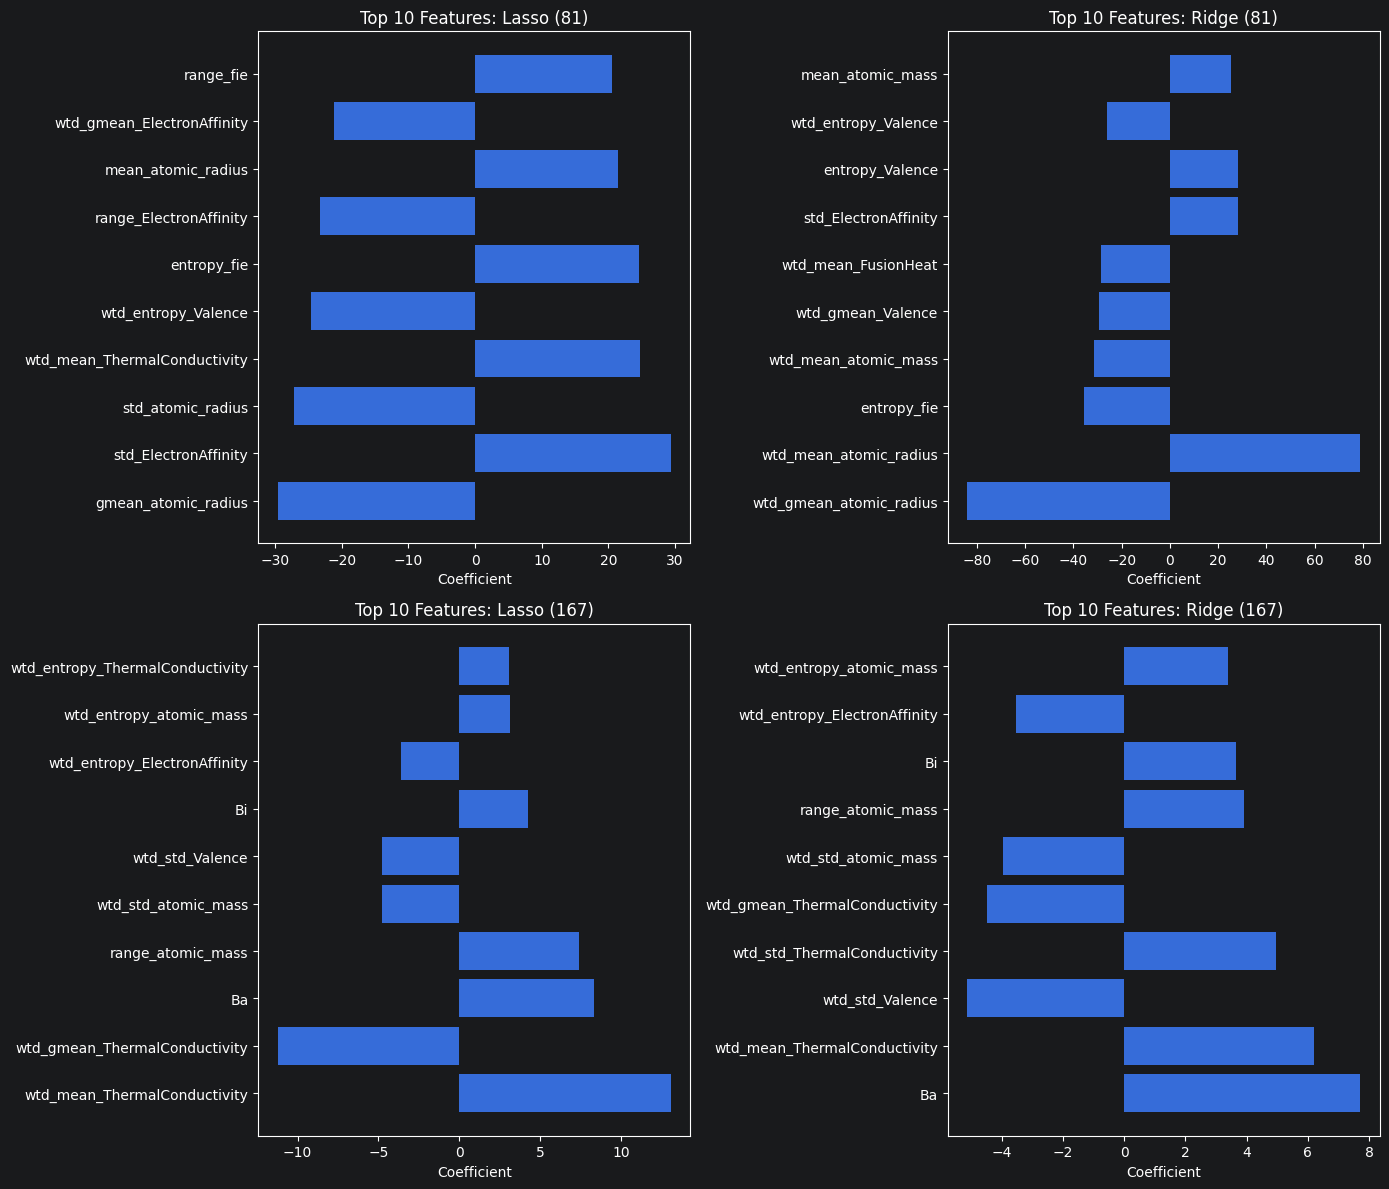

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes[0, 0].barh(lasso_top10_81['feature'], lasso_top10_81['coefficient'])
axes[0, 0].set_title('Top 10 Features: Lasso (81)')
axes[0, 0].set_xlabel('Coefficient')
axes[0, 1].barh(ridge_top10_81['feature'], ridge_top10_81['coefficient'])
axes[0, 1].set_title('Top 10 Features: Ridge (81)')
axes[0, 1].set_xlabel('Coefficient')
axes[1, 0].barh(lasso_top10_167['feature'], lasso_top10_167['coefficient'])
axes[1, 0].set_title('Top 10 Features: Lasso (167)')
axes[1, 0].set_xlabel('Coefficient')
axes[1, 1].barh(ridge_top10_167['feature'], ridge_top10_167['coefficient'])
axes[1, 1].set_title('Top 10 Features: Ridge (167)')
axes[1, 1].set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

## Conclusion

While neither regularization method improved meaningfully on the baseline linear regression model, the regularization process confirmed for us that the baseline model was not overfit, and the feature importance results give us interpretable insight into which material properties are most predictive of critical temperature.

### Why Regularization Had Little Effect

The consistent pattern across all six models is tied to the structure of this dataset.

The 81-feature dataset has 21,263 observations and 81 predictors, a ratio of roughly 262:1. With this many observations per feature, coefficient estimates are reliable without penalization. Regularization is most valuable when the sample-to-feature ratio is low, causing OLS to overfit on noise. That condition doesn't hold here.

The near-zero Lasso alphas reinforce this. A best alpha of 0.001 on the 81-feature dataset means the cross-validated search found that any meaningful penalty made the model worse — the unpenalized coefficients were already good estimates. The 167-feature L1 found a slightly higher alpha (0.178), because collinearity between the engineered and composition features gave L1 something to prune, but even there the regularized model underperforms the OLS baseline. The pruned features were carrying real signal, not noise.

The flat CV loss curve we observed for L2 on the 81-feature set tells the same story: regularization is solving a problem that doesn't exist for this dataset.